In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="mining_project",
    user="postgres",
    password="NewPassword123"
)

print("Connected successfully!")

Connected successfully!


In [9]:
import pandas as pd

query = "SELECT * FROM mineral_production;"

df = pd.read_sql(query, conn)

df.head()

C:\Users\vivek\AppData\Local\Temp\ipykernel_24760\3314181929.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,year,state,mineral,production,unit
0,1,2021-22,India,Bauxite,22494049.0,tonnes
1,2,2022-23,India,Bauxite,23844337.0,tonnes
2,3,2023-24,India,Bauxite,23967866.0,tonnes
3,4,2021-22,Chhattisgarh,Bauxite,968248.0,tonnes
4,5,2022-23,Chhattisgarh,Bauxite,1056576.0,tonnes


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          135 non-null    int64  
 1   year        135 non-null    object 
 2   state       135 non-null    object 
 3   mineral     135 non-null    object 
 4   production  135 non-null    float64
 5   unit        135 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 6.5+ KB


In [11]:
df.shape

(135, 6)

In [12]:
df.isnull().sum()

id            0
year          0
state         0
mineral       0
production    0
unit          0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.columns

Index(['id', 'year', 'state', 'mineral', 'production', 'unit'], dtype='object')

In [16]:
df.describe()

,id,production
count,135.000000,1.350000e+02
mean,68.000000,1.203639e+06
std,39.115214,4.230924e+06
min,1.000000,0.000000e+00
25%,34.500000,6.051000e+03
50%,68.000000,3.939500e+04
75%,101.500000,4.288365e+05
max,135.000000,2.396787e+07


In [17]:
df["state"].unique()

array(['India', 'Chhattisgarh', 'Gujarat', 'Jharkhand', 'Madhya Pradesh',
       'Maharashtra', 'Odisha', 'Andhra Pradesh', 'Karnataka',
       'Rajasthan', 'Telangana', 'Assam', 'Bihar', 'Himachal Pradesh',
       'Jammu and Kashmir', 'Kerala', 'Meghalaya', 'Tamil Nadu',
       'Uttar Pradesh', 'Uttarakhand', 'Goa'], dtype=object)

In [18]:
df["mineral"].unique()

array(['Bauxite', 'Manganese Ore', 'Limestone', 'Iron Ore'], dtype=object)

In [19]:
df["year"].unique()

array(['2021-22', '2022-23', '2023-24'], dtype=object)

In [20]:
df.groupby("mineral")["production"].sum().sort_values(ascending=False)

mineral
Bauxite          140612504.0
Manganese Ore     17799922.0
Limestone          2499414.0
Iron Ore           1579486.0
Name: production, dtype: float64

In [21]:
df.groupby("state")["production"].sum().sort_values(ascending=False)

state
India                81245963.0
Odisha               53700660.0
Jharkhand             6138156.0
Gujarat               5398142.0
Maharashtra           5186202.0
Madhya Pradesh        4723433.0
Chhattisgarh          3323808.0
Karnataka             1320112.0
Andhra Pradesh         880639.0
Rajasthan              307987.0
Telangana              108344.0
Tamil Nadu              72534.0
Himachal Pradesh        39395.0
Meghalaya               24580.0
Uttar Pradesh            8270.0
Assam                    5489.0
Jammu and Kashmir        3578.0
Bihar                    2915.0
Kerala                   1107.0
Goa                        12.0
Uttarakhand                 0.0
Name: production, dtype: float64

In [22]:
df.groupby("year")["production"].sum().sort_index()

year
2021-22    51665180.0
2022-23    54670554.0
2023-24    56155592.0
Name: production, dtype: float64

In [23]:
top_10 = (
    df.groupby(["state", "mineral"])["production"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_10

state           mineral      
India           Bauxite          70306252.0
Odisha          Bauxite          51444683.0
India           Manganese Ore     8900261.0
Jharkhand       Bauxite           6067363.0
Gujarat         Bauxite           5328635.0
Chhattisgarh    Bauxite           3058000.0
Madhya Pradesh  Manganese Ore     2734649.0
Maharashtra     Bauxite           2599534.0
                Manganese Ore     2516114.0
Madhya Pradesh  Bauxite           1808037.0
Name: production, dtype: float64

In [24]:
national_production = (
    df.groupby(["mineral", "year"])["production"]
      .sum()
      .reset_index()
      .sort_values(["mineral", "year"])
)

national_production

,mineral,year,production
0,Bauxite,2021-22,44988098.0
1,Bauxite,2022-23,47688674.0
2,Bauxite,2023-24,47935732.0
3,Iron Ore,2021-22,508198.0
4,Iron Ore,2022-23,516624.0
5,Iron Ore,2023-24,554664.0
6,Limestone,2021-22,784068.0
7,Limestone,2022-23,811328.0
8,Limestone,2023-24,904018.0
9,Manganese Ore,2021-22,5384816.0


In [25]:
yearly = (
    df.groupby(["state", "mineral", "year"])["production"]
      .sum()
      .reset_index()
      .sort_values(["state", "mineral", "year"])
)

yearly["previous_year_production"] = (
    yearly.groupby(["state", "mineral"])["production"].shift(1)
)

yearly["yoy_growth_pct"] = (
    (yearly["production"] - yearly["previous_year_production"])
    / yearly["previous_year_production"]
    * 100
)

yearly

,state,mineral,year,production,previous_year_production,yoy_growth_pct
0,Andhra Pradesh,Iron Ore,2021-22,319.0,NaN,NaN
1,Andhra Pradesh,Iron Ore,2022-23,185.0,319.0,-42.006270
2,Andhra Pradesh,Iron Ore,2023-24,125.0,185.0,-32.432432
3,Andhra Pradesh,Limestone,2021-22,50278.0,NaN,NaN
4,Andhra Pradesh,Limestone,2022-23,53526.0,50278.0,6.460082
...,...,...,...,...,...,...
130,Uttar Pradesh,Limestone,2022-23,2583.0,2809.0,-8.045568
131,Uttar Pradesh,Limestone,2023-24,2878.0,2583.0,11.420828
132,Uttarakhand,Limestone,2021-22,0.0,NaN,NaN
133,Uttarakhand,Limestone,2022-23,0.0,0.0,NaN


In [26]:
yearly["declined"] = (
    yearly["production"] < yearly["previous_year_production"]
)

declining_states = (
    yearly.groupby(["state", "mineral"])
          .agg(
              years_compared=("declined", "count"),
              years_declined=("declined", "sum")
          )
          .reset_index()
)

declining_states

,state,mineral,years_compared,years_declined
0,Andhra Pradesh,Iron Ore,3,2
1,Andhra Pradesh,Limestone,3,0
2,Andhra Pradesh,Manganese Ore,3,0
3,Assam,Limestone,3,0
4,Bihar,Limestone,3,1
5,Chhattisgarh,Bauxite,3,1
6,Chhattisgarh,Iron Ore,3,0
7,Chhattisgarh,Limestone,3,0
8,Goa,Iron Ore,3,0
9,Gujarat,Bauxite,3,2


In [27]:
declining_every_year = declining_states[
    declining_states["years_compared"] == declining_states["years_declined"]
]

declining_every_year

,state,mineral,years_compared,years_declined


In [28]:
latest_year = df["year"].max()

latest_year

'2023-24'

In [29]:
latest = df[df["year"] == latest_year]

top_5_latest = (
    latest.groupby(["mineral", "state"])["production"]
          .sum()
          .reset_index()
          .sort_values(["mineral", "production"], ascending=[True, False])
          .groupby("mineral")
          .head(5)
)

top_5_latest

,mineral,state,production
2,Bauxite,India,23967866.0
6,Bauxite,Odisha,17591967.0
3,Bauxite,Jharkhand,2043734.0
1,Bauxite,Gujarat,1643130.0
5,Bauxite,Maharashtra,1058581.0
10,Iron Ore,India,277332.0
15,Iron Ore,Odisha,148959.0
8,Iron Ore,Chhattisgarh,46043.0
12,Iron Ore,Karnataka,40996.0
11,Iron Ore,Jharkhand,22896.0


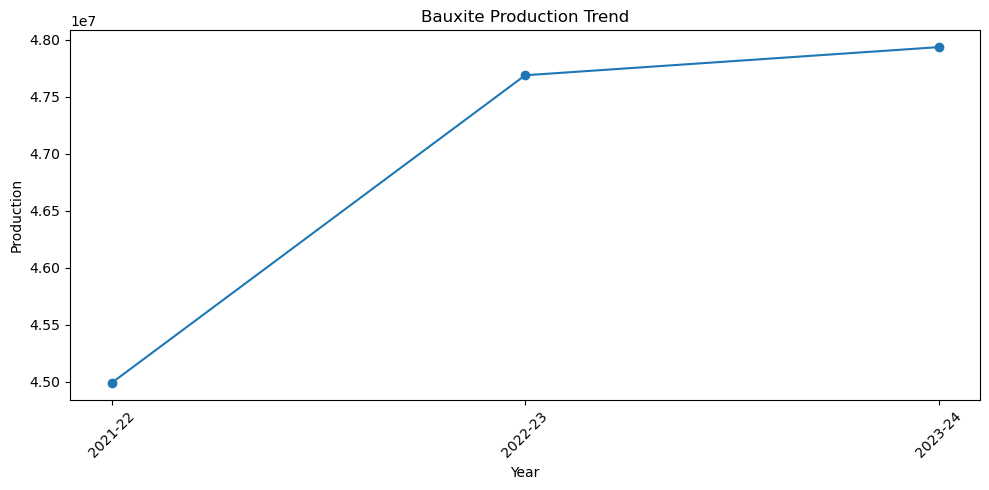

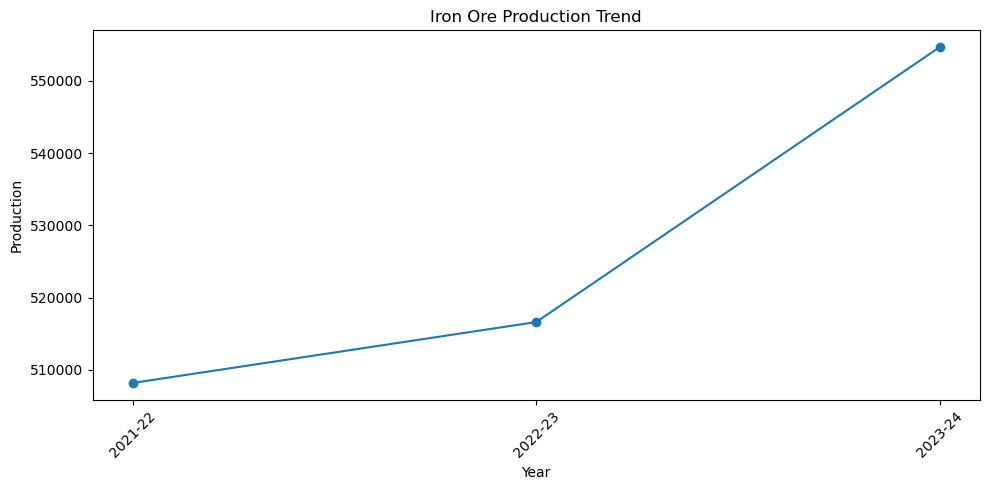

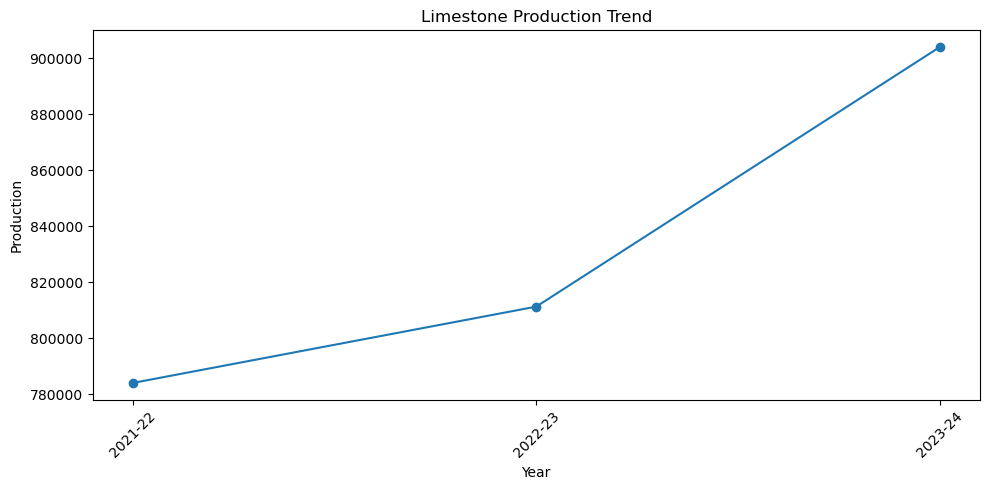

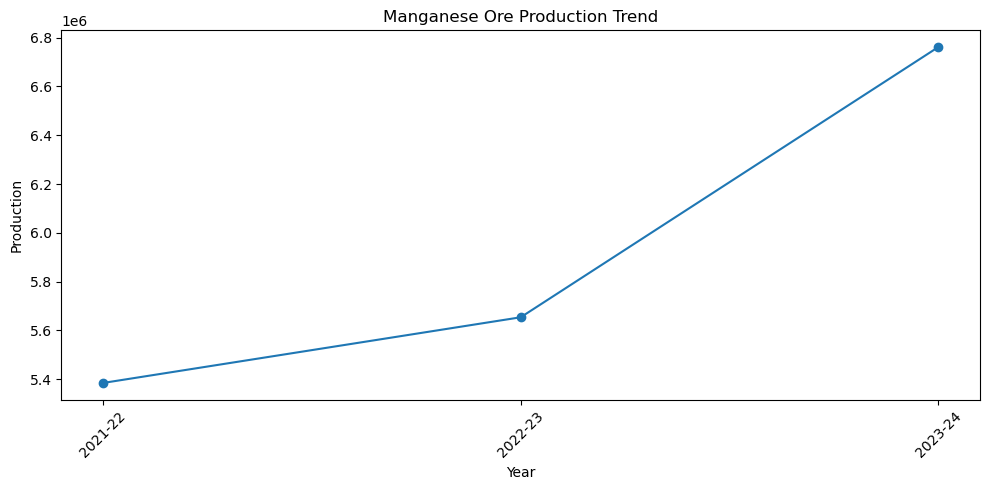

In [30]:
trend = (
    df.groupby(["year", "mineral"])["production"]
      .sum()
      .reset_index()
)

for mineral in trend["mineral"].unique():
    data = trend[trend["mineral"] == mineral]
    
    plt.figure(figsize=(10, 5))
    plt.plot(data["year"], data["production"], marker="o")
    plt.title(f"{mineral} Production Trend")
    plt.xlabel("Year")
    plt.ylabel("Production")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

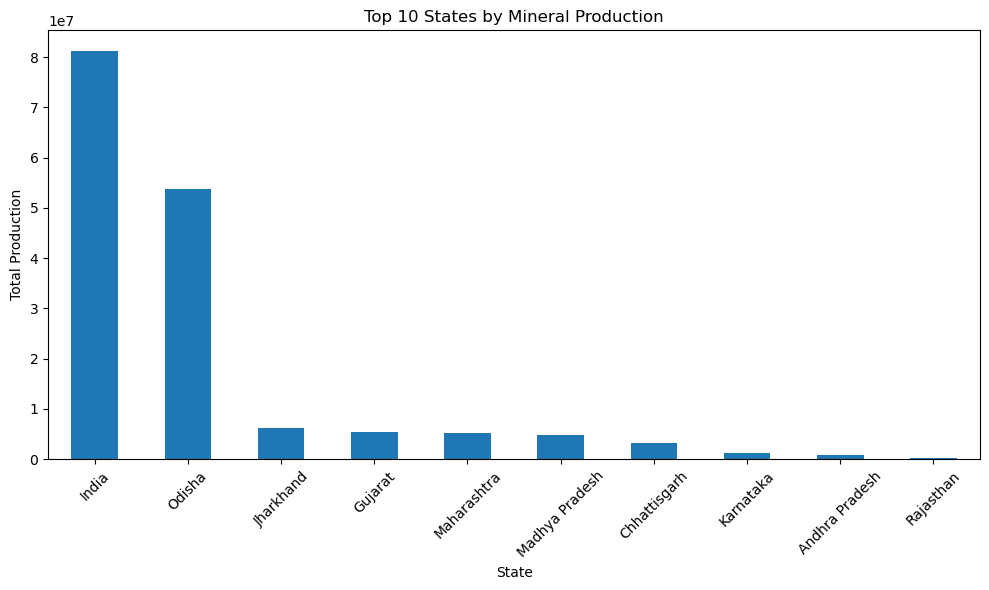

In [31]:
state_production = (
    df.groupby("state")["production"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
state_production.plot(kind="bar")
plt.title("Top 10 States by Mineral Production")
plt.xlabel("State")
plt.ylabel("Total Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

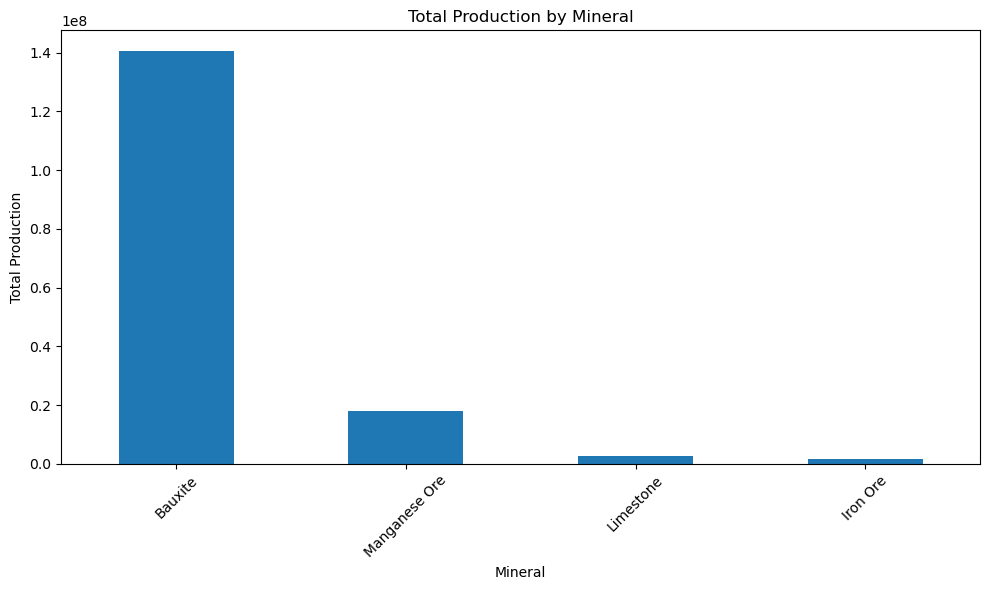

In [32]:
mineral_production = (
    df.groupby("mineral")["production"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
mineral_production.plot(kind="bar")
plt.title("Total Production by Mineral")
plt.xlabel("Mineral")
plt.ylabel("Total Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
df.to_csv("mineral_production_clean.csv", index=False)

print("CSV exported successfully!")

CSV exported successfully!


In [34]:
top_10.to_csv("top_10_state_mineral.csv")

national_production.to_csv(
    "national_production_by_year.csv",
    index=False
)

top_5_latest.to_csv(
    "top_5_latest_year.csv",
    index=False
)

declining_every_year.to_csv(
    "declining_states.csv",
    index=False
)

print("Analysis files exported successfully!")

Analysis files exported successfully!


In [35]:
conn.close()

print("PostgreSQL connection closed.")

PostgreSQL connection closed.


In [4]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\vivek
['.anaconda', '.android', '.cache', '.codex', '.conda', '.continuum', '.copilot', '.emulator_console_auth_token', '.gradle', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.node_repl_history', '.virtual_documents', '.vscode', '.vscode-shared', 'AdventureWorks Sales.xlsx', 'AdventureWorks_Sales_Analysis.csv', 'AdventureWork_Analysis.ipynb', 'anaconda3', 'AndroidStudioProjects', 'app.py', 'AppData', 'Application Data', 'CampusConnect', 'Contacts', 'Cookies', 'CrossDevice', 'Customer Behavior Cleaned.csv', 'Customer Behavior Cleaned.pkl', 'customer_behavior_analysis.ipynb', 'customer_shopping_behavior.csv', 'declining_states.csv', 'Desktop', 'Documents', 'Downloads', 'Dropbox', 'employee.csv', 'Favorites', 'hello.py', 'Links', 'Local Settings', 'Medicine Assistant System', 'Microsoft', 'mineral_production_clean.csv', 'Mining_Production_Analysis.ipynb', 'Music', 'My Documents', 'national_production_by_year.csv', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntu

In [2]:
import pandas as pd
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="mining_project",
    user="postgres",
    password="NewPassword123"
)

df = pd.read_sql("SELECT * FROM mineral_production", conn)

print(df.shape)
df.head()

(135, 6)


C:\Users\vivek\AppData\Local\Temp\ipykernel_12164\2302720457.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM mineral_production", conn)


,id,year,state,mineral,production,unit
0,1,2021-22,India,Bauxite,22494049.0,tonnes
1,2,2022-23,India,Bauxite,23844337.0,tonnes
2,3,2023-24,India,Bauxite,23967866.0,tonnes
3,4,2021-22,Chhattisgarh,Bauxite,968248.0,tonnes
4,5,2022-23,Chhattisgarh,Bauxite,1056576.0,tonnes


In [6]:
yearly = (
    df.groupby(["state", "mineral", "year"])["production"]
    .sum()
    .reset_index()
    .sort_values(["state", "mineral", "year"])
)

yearly["previous_year_production"] = (
    yearly.groupby(["state", "mineral"])["production"].shift(1)
)

yearly["declined"] = (
    yearly["production"] < yearly["previous_year_production"]
)

In [4]:
declining_states = (
    yearly.groupby(["state", "mineral"])
    .agg(
        years_compared=("declined", "count"),
        years_declined=("declined", "sum")
    )
    .reset_index()
)

declining_every_year = declining_states[
    declining_states["years_compared"] == declining_states["years_declined"]
]

print(declining_every_year)
print(declining_every_year.shape)

Empty DataFrame
Columns: [state, mineral, years_compared, years_declined]
Index: []
(0, 4)


In [5]:
declining_every_year.to_csv(
    "declining_states.csv",
    index=False
)

print("declining_states.csv exported successfully!")

declining_states.csv exported successfully!


In [7]:
declining_every_year = declining_states[
    declining_states["years_declined"] >= 2
]

print(declining_every_year)
print(declining_every_year.shape)

             state        mineral  years_compared  years_declined
0   Andhra Pradesh       Iron Ore               3               2
9          Gujarat        Bauxite               3               2
18       Jharkhand       Iron Ore               3               2
24  Madhya Pradesh        Bauxite               3               2
39       Rajasthan  Manganese Ore               3               2
41       Telangana      Limestone               3               2
(6, 4)


In [8]:
declining_every_year.to_csv("declining_every_year.csv", index=False)

print("declining_every_year.csv exported successfully!")

declining_every_year.csv exported successfully!
